In [48]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df=pd.read_excel("global_superstore_2016.xlsx")

In [7]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,40098,CA-2014-AB10015140-41954,2014-11-11,2014-11-13,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,...,TEC-PH-5816,Technology,Phones,Samsung Convoy 3,221.980,2,0.0,62.1544,40.77,High
1,26341,IN-2014-JR162107-41675,2014-02-05,2014-02-07,Second Class,JR-162107,Justin Ritter,Corporate,NaN,Wollongong,...,FUR-CH-5379,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2014-CR127307-41929,2014-10-17,2014-10-18,First Class,CR-127307,Craig Reiter,Consumer,NaN,Brisbane,...,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2014-KM1637548-41667,2014-01-28,2014-01-30,First Class,KM-1637548,Katherine Murray,Home Office,NaN,Berlin,...,TEC-PH-5267,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2014-RH9495111-41948,2014-11-05,2014-11-06,Same Day,RH-9495111,Rick Hansen,Consumer,NaN,Dakar,...,TEC-CO-6011,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [8]:
df.shape

(51290, 24)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51290 non-null  int64         
 1   Order ID        51290 non-null  object        
 2   Order Date      51290 non-null  datetime64[ns]
 3   Ship Date       51290 non-null  datetime64[ns]
 4   Ship Mode       51290 non-null  object        
 5   Customer ID     51290 non-null  object        
 6   Customer Name   51290 non-null  object        
 7   Segment         51290 non-null  object        
 8   Postal Code     9994 non-null   float64       
 9   City            51290 non-null  object        
 10  State           51290 non-null  object        
 11  Country         51290 non-null  object        
 12  Region          51290 non-null  object        
 13  Market          51290 non-null  object        
 14  Product ID      51290 non-null  object        
 15  Ca

In [12]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Postal Code', 'City',
       'State', 'Country', 'Region', 'Market', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Cost', 'Order Priority'],
      dtype='object')

In [14]:
df.isnull().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
Postal Code       41296
City                  0
State                 0
Country               0
Region                0
Market                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

In [17]:
df.columns = df.columns.str.strip()

In [18]:
df['Postal Code'].dtype

dtype('float64')

In [20]:
df.columns = df.columns.str.strip()


In [ ]:
df.isnull().sum()

In [ ]:
for col in df.select_dtypes(include=['float64','int64']).columns:
    df[col] = df[col].fillna(df[col].median())

In [22]:
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [23]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Postal Code       0
City              0
State             0
Country           0
Region            0
Market            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
Shipping Cost     0
Order Priority    0
dtype: int64

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [26]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

In [27]:
total_sales = df['Sales'].sum()

In [28]:
total_sales

np.float64(12642501.90988)

In [29]:
total_profit = df['Profit'].sum()

In [30]:
total_profit

np.float64(1467457.2912799998)

In [31]:
profit_margin = (total_profit / total_sales) * 100

In [32]:
profit_margin

np.float64(11.607332960995603)

In [33]:
total_orders = df['Order ID'].nunique()

In [34]:
total_orders

25728

## Sales By Region

In [35]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

In [36]:
region_sales

Region
Western Europe       1.731930e+06
Central America      1.223101e+06
Oceania              1.100185e+06
Southeastern Asia    8.844232e+05
Southern Asia        8.665727e+05
Eastern Asia         8.550594e+05
Western US           7.254578e+05
Eastern US           6.787812e+05
Northern Europe      6.367792e+05
South America        6.172237e+05
Southern Europe      6.085940e+05
Central US           5.012399e+05
Southern US          3.917219e+05
Caribbean            3.242809e+05
Western Asia         3.171070e+05
Eastern Europe       3.100334e+05
North Africa         2.332166e+05
Western Africa       1.738788e+05
Central Africa       1.436300e+05
Eastern Africa       1.278560e+05
Southern Africa      1.051918e+05
Canada               6.692817e+04
Central Asia         1.931146e+04
Name: Sales, dtype: float64

## Profit By Category

In [37]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

In [38]:
category_profit

Category
Technology         663778.73318
Office Supplies    518595.82790
Furniture          285082.73020
Name: Profit, dtype: float64

## Top 10 Products by Profit

In [39]:
top_products = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)

In [40]:
top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                       25199.9280
Cisco Smart Phone, Full Size                                17238.5206
Motorola Smart Phone, Full Size                             17027.1130
Hoover Stove, Red                                           11807.9690
Sauder Classic Bookcase, Traditional                        10672.0730
Harbour Creations Executive Leather Armchair, Adjustable    10427.3260
Nokia Smart Phone, Full Size                                 9938.1955
Cisco Smart Phone, with Caller ID                            9786.6408
Nokia Smart Phone, with Caller ID                            9465.3257
Belkin Router, USB                                           8955.0180
Name: Profit, dtype: float64

## Loss Making Products

In [43]:
loss_products =df.groupby('Product Name')['Profit'].sum().sort_values().head(10)

In [44]:
loss_products

Product Name
Cubify CubeX 3D Printer Double Head Print                  -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                  -4589.9730
Motorola Smart Phone, Cordless                             -4447.0380
Cubify CubeX 3D Printer Triple Head Print                  -3839.9904
Bevis Round Table, Adjustable Height                       -3649.8940
Bevis Computer Table, Fully Assembled                      -3509.5638
Rogers Lockers, Blue                                       -2893.4908
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases   -2876.1156
Bevis Wood Table, with Bottom Storage                      -2782.5880
Lesro Training Table, Rectangular                          -2581.2834
Name: Profit, dtype: float64

## Discount Impact

In [45]:
df[['Discount','Profit']].corr()

,Discount,Profit
Discount,1.00000,-0.31649
Profit,-0.31649,1.00000


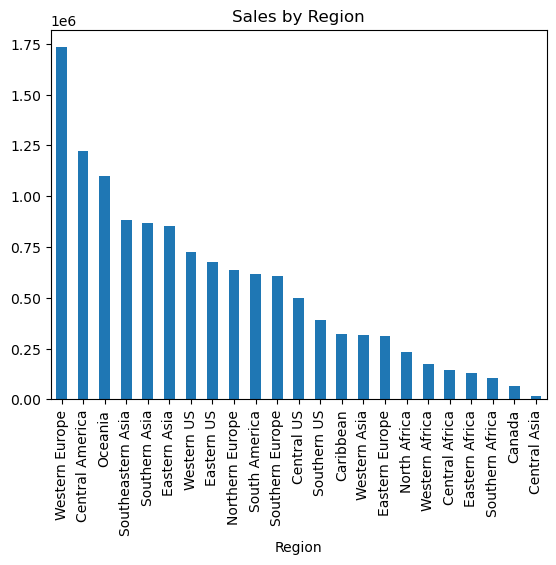

In [49]:
region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.show()

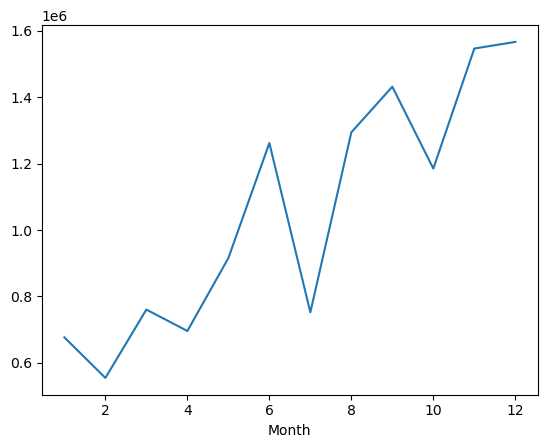

In [55]:
monthly_sales = df.groupby('Month')['Sales'].sum()
monthly_sales.plot(kind='line')
plt.show()

In [61]:
df.to_csv("cleaned_sales_data.csv", 
          index=False, 
          encoding="utf-8-sig")
